In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from obspy import Inventory, UTCDateTime, read
from obspy.clients.fdsn import Client
dpath = '/Users/oxide/Documents/research/orenstein/code/P288FinalProject/alex/data/'
processed_dpath = '/Users/oxide/Documents/research/orenstein/code/P288FinalProject/alex/processed_data/'

def deduplicate_datetime_index(df, strategy='first'):
    """
    Remove duplicate timestamps from a DataFrame, handling both numeric and non-numeric data.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with DatetimeIndex that may contain duplicates
    strategy : str or dict
        How to handle duplicates:
        - 'first': Keep first occurrence (default)
        - 'last': Keep last occurrence
        - 'mean': Average numeric columns, first for non-numeric
        - 'median': Median for numeric, first for non-numeric
        - dict: Column-specific strategies, e.g., {'col1': 'mean', 'col2': 'first'}
    
    Returns
    -------
    pd.DataFrame
        DataFrame with unique timestamps
    """
    if not df.index.has_duplicates:
        return df.copy()
    
    if strategy == 'first':
        return df[~df.index.duplicated(keep='first')]
    
    elif strategy == 'last':
        return df[~df.index.duplicated(keep='last')]
    
    elif strategy in ['mean', 'median']:
        # Group by index and apply appropriate aggregation
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
        
        result_parts = []
        
        # Handle numeric columns
        if len(numeric_cols) > 0:
            if strategy == 'mean':
                numeric_agg = df[numeric_cols].groupby(level=0).mean()
            else:  # median
                numeric_agg = df[numeric_cols].groupby(level=0).median()
            result_parts.append(numeric_agg)
        
        # Handle non-numeric columns (take first)
        if len(non_numeric_cols) > 0:
            non_numeric_agg = df[non_numeric_cols].groupby(level=0).first()
            result_parts.append(non_numeric_agg)
        
        # Combine and restore original column order
        result = pd.concat(result_parts, axis=1)
        return result[df.columns]
    
    elif isinstance(strategy, dict):
        # Column-specific strategies
        result_parts = []
        
        for col in df.columns:
            col_strategy = strategy.get(col, 'first')
            
            if col_strategy == 'first':
                agg_col = df[[col]].groupby(level=0).first()
            elif col_strategy == 'last':
                agg_col = df[[col]].groupby(level=0).last()
            elif col_strategy == 'mean':
                agg_col = df[[col]].groupby(level=0).mean()
            elif col_strategy == 'median':
                agg_col = df[[col]].groupby(level=0).median()
            elif col_strategy == 'min':
                agg_col = df[[col]].groupby(level=0).min()
            elif col_strategy == 'max':
                agg_col = df[[col]].groupby(level=0).max()
            elif col_strategy == 'sum':
                agg_col = df[[col]].groupby(level=0).sum()
            else:
                raise ValueError(f"Unknown strategy '{col_strategy}' for column '{col}'")
            
            result_parts.append(agg_col)
        
        return pd.concat(result_parts, axis=1)
    
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

def parse_dates(date_string):
    # Try different format patterns
    formats = [
        "%Y-%m-%d %H:%M:%S.%f",       # Format 1
        "%Y-%m-%d_%H%M%S",            # Format 2
        "%Y-%m-%d %H:%M:%S"         # Format 3
    ]
    
    for fmt in formats:
        try:
            return datetime.strptime(date_string, fmt)
        except ValueError:
            continue

def set_datetime(df, time_index='Datetime'):
    """
    sets uniform datetime format for pandas dataframes and sets the datetime as index.
    """
    df[time_index] = pd.to_datetime(df[time_index],utc=True)
    df = df.set_index(time_index)
    # Handle duplicates
    df = deduplicate_datetime_index(df)
    return df

def interpolate_to_index(df, target_index, method='linear'):
    """
    Interpolate dataframe to a new DatetimeIndex.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with DatetimeIndex
    target_index : pd.DatetimeIndex
        Target index to interpolate to
    method : str
        Interpolation method: 'linear', 'time', 'nearest', 'cubic', etc.
    
    Returns
    -------
    pd.DataFrame
        Interpolated dataframe
    """

    # Combine original and target indices, then sort
    combined_index = df.index.union(target_index).sort_values()
    
    # Reindex to combined index (fills with NaN)
    df_reindexed = df.reindex(combined_index)
    
    # Interpolate (method='time' is good for irregular time series)
    df_interpolated = df_reindexed.interpolate(method=method)
    
    # Select only the target index
    return df_interpolated.reindex(target_index)

def combine_and_interpolate(dataframes, target_times):
    """
    Interpolates data in dataframes onto target_times. Each dataframe must have 'Datetime' as index.
    """
    
    interpolated_dfs = []
    for df in dataframes:
        
        # interpolate and append - can change interpolate_to_index function for different desired interpolation
        interpolated_dfs.append(interpolate_to_index(df, target_times))
    
    interpolated = pd.concat(interpolated_dfs, axis=1)

    # remove non-numerical columns
    interpolated = interpolated.select_dtypes(include=[np.number])

    return interpolated

def resample_acoustic(data, target_index, dt='1min'):
    """
    resample acoustic data into magnitude vs time onto a specific target grid
    """
    
    magnitude = pd.Series(0.0, index=target_index)
    for _, event in data.iterrows():
        t1 = event['Acoustic t1']
        t2 = event['Acoustic t2']
        
        value = event['Magnitude'] # can change this line to redefine "eruption activity"

        affected_bins = target_index[(target_index <= t2) & (target_index + pd.Timedelta(dt) >= t1)]
        
        for bin_start in affected_bins:
            bin_end = bin_start + pd.Timedelta(dt)
            overlap_start = max(t1, bin_start)
            overlap_end = min(t2, bin_end)
            overlap_seconds = (overlap_end - overlap_start).total_seconds()
            
            if overlap_seconds > 0:
                fraction = overlap_seconds / bin_duration_seconds # smoothing of the data a bit
                magnitude[bin_start] += value * fraction

    magnitude = magnitude.to_frame(name='Erruption Activity')
    
    return magnitude

<Axes: >

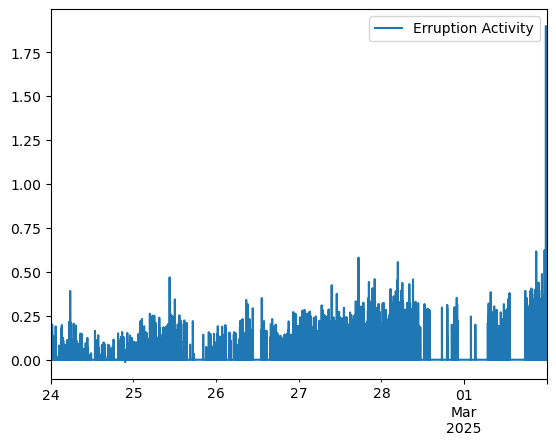

In [75]:
# define times over which to interpolate (1 minute increments between start and end date)
target_times = pd.date_range(date_range[0], date_range[1], freq='min')
acoustic_interpolated = resample_acoustic(acoustic, target_times)

acoustic_interpolated['2025-02-24':'2025-03-01'].plot()

In [63]:
date_range = pd.to_datetime(["2025-01-22 0:0:0.0", "2025-03-16 00:00:00.0"], utc=True)

# load POAS acoustic data
acoustic = pd.read_csv(dpath+'Poas_discrete_2025-01-22_2025-03-15.csv', header=1, names=['Event ID', 'Label', 'Station', 'Sensor Type','Acoustic t1', 'Acoustic t2', 'Energy' ,'Duration', 'Magnitude'])
acoustic['Acoustic t1'] = pd.to_datetime(acoustic['Acoustic t1'],utc=True)
acoustic['Acoustic t2'] = pd.to_datetime(acoustic['Acoustic t2'],utc=True)
acoustic['Datetime'] = pd.to_datetime((acoustic['Acoustic t1'].astype('int64') + acoustic['Acoustic t2'].astype('int64')) / 2) # mean time
acoustic = set_datetime(acoustic)
acoustic.name = 'acoustic'

# load seismic data from Sarah
seismic_data = []
for station in ['VPCC', 'VPPC', 'VPNC', 'VPRS']: #
    df = pd.read_csv(dpath+f'{station}_RSAM_600s_merged.csv', header=2, names=['Datetime', f'{station} RSAM', 'Station', 'Channel', 'Year', 'Month'])
    df = set_datetime(df)
    df.name = f'{station}_seismic'
    seismic_data.append(df)

# load magnetic data
magnetic_data = []
for station in ['VPRS']:
    traceE = read(dpath+f'OV.{station}_LFE.m')[0]
    traceN = read(dpath+f'OV.{station}_LFN.m')[0]
    traceZ = read(dpath+f'OV.{station}_LFZ.m')[0]
    timeseriesE = np.array(traceE)
    timeseriesN = np.array(traceN)
    timeseriesZ = np.array(traceZ)
    times = np.array([t.datetime for t in traceE.times(type='utcdatetime')])
    column_names = ['Datetime', f'{station} Field E', f'{station} Field N', f'{station} Field Z']
    df = pd.DataFrame(zip(times, timeseriesE, timeseriesN, timeseriesZ), columns=column_names)
    df = set_datetime(df)
    df.name = f'{station}_magnetic'
    magnetic_data.append(df)

# load soil CO2 data
soilCO2 = pd.read_csv(dpath+'CO2.csv', header=1, names=['Datetime', 'CO2 concentration'])
soilCO2 = set_datetime(soilCO2)
soilCO2.name = 'soilCO2'

# load weather
df1 = pd.read_csv(dpath+'VPMI_weather_2024.csv', delimiter=',', header=0)
df2 = pd.read_csv(dpath+'VPMI_weather_2025.csv', delimiter=',', header=0)
weather = pd.concat([df1, df2])
weather['Datetime'] = [parse_dates(dt) for dt in weather['Datetime']]
weather = set_datetime(weather)
weather.name = 'weather'

In [72]:
# define times over which to interpolate (1 minute increments between start and end date)
target_times = pd.date_range(date_range[0], date_range[1], freq='min')

# interpolate acoustic data
acoustic_interpolated = resample_acoustic(acoustic, target_times)

# combine and interpolate
dataframes = [*seismic_data, *magnetic_data, soilCO2, weather, acoustic_interpolated] # all dataframes to combine
interpolated = combine_and_interpolate(dataframes, target_times)
interpolated.name = 'dataInterpolated'

# save loaded dataframes as CSV
#for df in dataframes:
    #df.to_csv(processed_dpath+f'{df.name}.csv')
# save acoustic data
#acoustic.to_csv(processed_dpath+f'{acoustic.name}.csv')

# save combined interpolated data as CSV
interpolated.to_csv(processed_dpath+f'{interpolated.name}.csv')

/var/folders/q_/x7kgmf911jj3y340hrv7mlp00000gn/T/ipykernel_11113/3684276585.py:145: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_interpolated = df_reindexed.interpolate(method=method)
/var/folders/q_/x7kgmf911jj3y340hrv7mlp00000gn/T/ipykernel_11113/3684276585.py:145: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_interpolated = df_reindexed.interpolate(method=method)
/var/folders/q_/x7kgmf911jj3y340hrv7mlp00000gn/T/ipykernel_11113/3684276585.py:145: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_interpolated = df_reindexed.interpolate(method=method)
/var/folders/q_/x7kgmf911jj3y340hrv7mlp00000gn/T/ipykernel

In [73]:
interpolated

,VPCC RSAM,Year,Month,VPPC RSAM,Year,Month,VPNC RSAM,Year,Month,VPRS RSAM,...,Vh,Vs,Vr,Rc,Rd,Ri,Hc,Hd,Hi,column_name
2025-01-22 00:00:00+00:00,22.752072,2025.0,1.0,553.258726,2025.0,1.0,205.800188,2025.0,1.0,70.380941,...,0.0,12.600000,3.649250,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-01-22 00:01:00+00:00,22.435684,2025.0,1.0,557.623803,2025.0,1.0,205.669567,2025.0,1.0,70.069737,...,0.0,12.595652,3.649957,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-01-22 00:02:00+00:00,22.119297,2025.0,1.0,561.988880,2025.0,1.0,205.538947,2025.0,1.0,69.758534,...,0.0,12.591304,3.649913,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-01-22 00:03:00+00:00,21.802909,2025.0,1.0,566.353958,2025.0,1.0,205.408326,2025.0,1.0,69.447330,...,0.0,12.586957,3.649870,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-01-22 00:04:00+00:00,21.486522,2025.0,1.0,570.719035,2025.0,1.0,205.277706,2025.0,1.0,69.136127,...,0.0,12.582609,3.649826,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-15 23:56:00+00:00,33.455283,2025.0,3.0,2702.798913,2025.0,3.0,652.088431,2025.0,3.0,54.370755,...,0.0,12.930435,3.649000,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-03-15 23:57:00+00:00,31.759351,2025.0,3.0,2714.147283,2025.0,3.0,650.382704,2025.0,3.0,54.079588,...,0.0,12.926087,3.649000,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-03-15 23:58:00+00:00,30.063418,2025.0,3.0,2725.495653,2025.0,3.0,648.676977,2025.0,3.0,53.788420,...,0.0,12.921739,3.649000,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2025-03-15 23:59:00+00:00,28.367486,2025.0,3.0,2736.844024,2025.0,3.0,646.971249,2025.0,3.0,53.497253,...,0.0,12.917391,3.649000,NaN,NaN,NaN,NaN,NaN,NaN,0.0
